# Pipeline complet

> **Authorship note.** Claude Opus was used to help generate code and polish the writing in this notebook. The choice of methods, analysis of limitations, and interpretation of results were done by the author.

Notebook bout-en-bout : EDA → jeux train/valid/test → entraînement (4 modèles) → évaluation d'équité → interprétabilité SHAP → analyse de robustesse → conclusions.

| Section | Contenu |
|---------|--------|
| 1 | EDA : biais des taux de toxicité selon les groupes identitaires |
| 2 | Données : splits, tokenizer, pondérations d'importance |
| 3 | Modèles : ToxicityGRU et FairGRU |
| 4 | Entraînement : Baseline · Répondération · Adversarial · Combiné |
| 5 | Évaluation : AUC globale et métriques d'équité |
| 6 | SHAP : importance au niveau token par modèle |
| 7 | Robustesse : AUC sous bruit, dropout, troncature |
| 8 | Conclusions |

In [1]:
import warnings; warnings.filterwarnings('ignore')
import os, json, math, numpy as np, pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torch.autograd import Function
from sklearn.metrics import roc_auc_score, classification_report
import matplotlib.pyplot as plt
from transformers import BertTokenizer
from fairness_jigsaw.metrics import DEFAULT_IDENTITY_COLUMNS, ModelBiasEvaluator

try:
    import shap; HAS_SHAP = True
except ImportError:
    print('shap not installed. Run: pip install shap'); HAS_SHAP = False

DEVICE = (
    torch.device('cuda') if torch.cuda.is_available()
    else torch.device('mps') if torch.backends.mps.is_available()
    else torch.device('cpu')
)
print(f'Device: {DEVICE}')

SEED = 42; torch.manual_seed(SEED); np.random.seed(SEED)
TOXICITY_THRESHOLD = 0.5; IDENTITY_THRESHOLD = 0.5
N_TRAIN_SAMPLE = None   # set to int (e.g. 200_000) for fast iteration
MAX_LEN = 128; EMBED_DIM = 64; HIDDEN_DIM = 128
BATCH_SIZE = 256; EPOCHS = 3; LR = 1e-3
LAMBDA_ADV = 0.5; ADV_ALPHA = 2.0
ROBUSTNESS_N = 5_000   # test-set subsample for robustness
SHAP_N = 20            # examples for SHAP

Device: mps


## 1. EDA

Questions clés : quels groupes identitaires sont surreprésentés dans les commentaires toxiques ? Quelle est l'ampleur de la disparité ?


Full corpus: 1,804,874  toxic=8.00%
Annotated  : 405,130  toxic=11.36%  (22.4% of corpus, 1.4x more toxic — annotation over-sampling)

Method 1 — Representation: 5 identities exceed 1%-of-corpus power threshold
Top 8: female(3.0%), male(2.5%), christian(2.2%), white(1.4%), muslim(1.2%), black(0.8%), homosexual_gay_or_lesbian(0.6%), jewish(0.4%)

Methods 2+3 — bias summary (baseline=11.36%):
                     identity     n toxic_rate  lift dp_gap partial_r
                        black 14901      31.4% 2.76x +20.0%    +0.114
    homosexual_gay_or_lesbian 10997      28.4% 2.50x +17.0%    +0.120
                        white 25082      28.1% 2.47x +16.7%    +0.158
                 heterosexual  1291      22.8% 2.00x +11.4%    +0.004
                       muslim 21006      22.8% 2.00x +11.4%    +0.133
                     bisexual   287      21.6% 1.90x +10.2%    -0.006
                  transgender  2499      21.3% 1.87x  +9.9%    +0.029
psychiatric_or_mental_illness  4889      21.1%

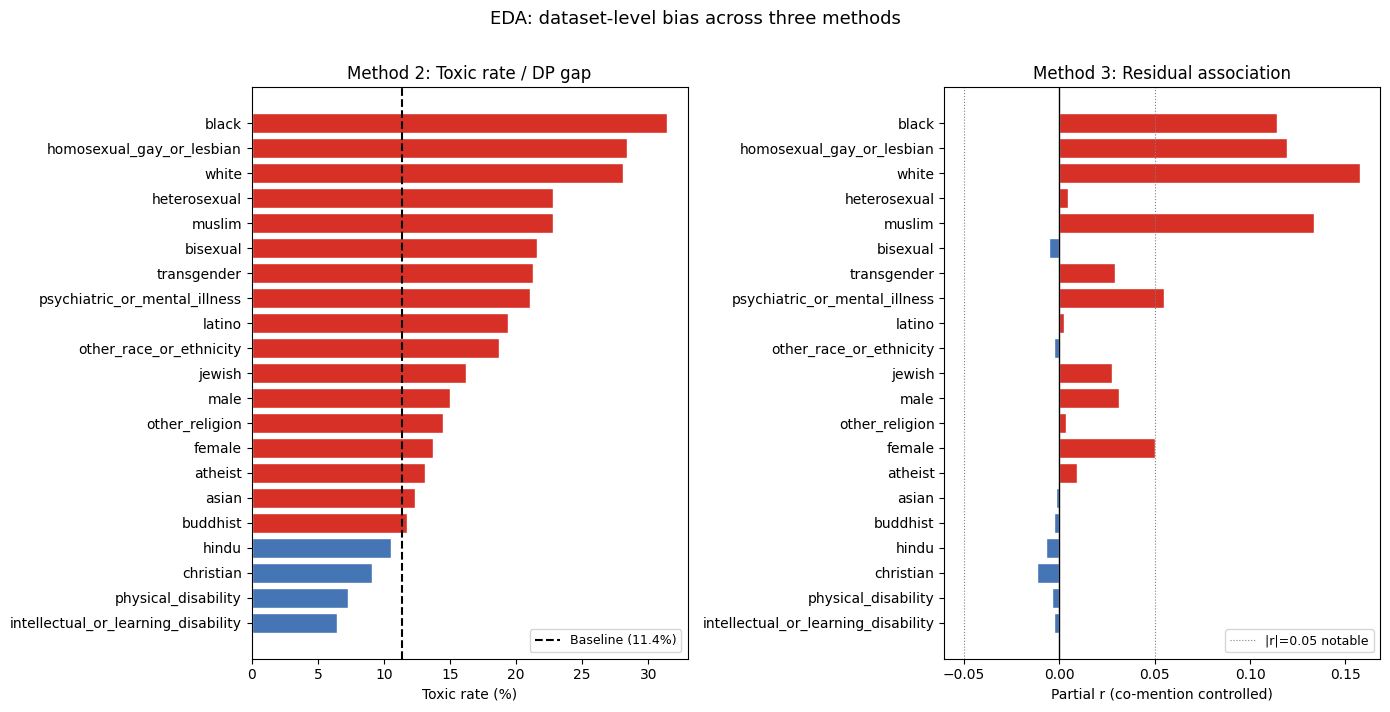

In [2]:
from scipy import stats
from sklearn.linear_model import LinearRegression

# Load EDA data (no text column needed)
df_eda = pd.read_csv('../data/train.csv', usecols=['target'] + list(DEFAULT_IDENTITY_COLUMNS))
df_eda['toxic'] = (df_eda['target'] >= TOXICITY_THRESHOLD).astype(int)
for col in DEFAULT_IDENTITY_COLUMNS:
    df_eda[f'{col}_bin'] = (df_eda[col].fillna(0) >= IDENTITY_THRESHOLD).astype(int)
bin_cols  = [f'{col}_bin' for col in DEFAULT_IDENTITY_COLUMNS]
anno_mask = df_eda[list(DEFAULT_IDENTITY_COLUMNS)].notna().any(axis=1)
df_anno   = df_eda[anno_mask].copy().reset_index(drop=True)
tox_base  = df_anno['toxic'].mean()
N_FULL    = len(df_eda)

print(f'Full corpus: {N_FULL:,}  toxic={df_eda["toxic"].mean():.2%}')
print(f'Annotated  : {len(df_anno):,}  toxic={tox_base:.2%}  '
      f'({len(df_anno)/N_FULL:.1%} of corpus, {tox_base/df_eda["toxic"].mean():.1f}x more toxic — annotation over-sampling)')

# ── Method 1: Representation imbalance ───────────────────────────────────────
rep      = df_eda[bin_cols].sum().rename(lambda x: x.replace('_bin', ''))
rep_rate = rep / N_FULL
above_1pct = int((rep_rate >= 0.01).sum())
print(f'\nMethod 1 — Representation: {above_1pct} identities exceed 1%-of-corpus power threshold')
print('Top 8:', ', '.join(f'{k}({v:.1%})' for k, v in rep_rate.sort_values(ascending=False).head(8).items()))

# ── Method 2: Toxic rate / Lift / DP gap ─────────────────────────────────────
dp_records = []
for col in DEFAULT_IDENTITY_COLUMNS:
    sub = df_anno[df_anno[f'{col}_bin'] == 1]
    if len(sub) < 50:
        continue
    rate = sub['toxic'].mean()
    dp_records.append({'identity': col, 'n': len(sub),
                       'toxic_rate': rate, 'lift': rate / tox_base,
                       'dp_gap': rate - tox_base})
dp_df = pd.DataFrame(dp_records).sort_values('dp_gap', ascending=True).reset_index(drop=True)

# ── Method 3: Partial correlation (net of co-mentions) ───────────────────────
bm     = df_anno[bin_cols].to_numpy(float)
y_anno = df_anno['target'].to_numpy()
pc_records = []
for i, col in enumerate(DEFAULT_IDENTITY_COLUMNS):
    ctrl = [j for j in range(len(DEFAULT_IDENTITY_COLUMNS)) if j != i]
    X    = bm[:, ctrl]
    rx   = bm[:, i] - LinearRegression().fit(X, bm[:, i]).predict(X)
    ry   = y_anno   - LinearRegression().fit(X, y_anno).predict(X)
    if rx.std() == 0:
        continue
    r, _ = stats.pearsonr(rx, ry)
    pc_records.append({'identity': col, 'partial_r': r})
pc_df = pd.DataFrame(pc_records).sort_values('partial_r', ascending=False).reset_index(drop=True)

# ── Combined summary ──────────────────────────────────────────────────────────
summary = dp_df.merge(pc_df, on='identity').sort_values('dp_gap', ascending=False)
print(f'\nMethods 2+3 — bias summary (baseline={tox_base:.2%}):')
print(summary[['identity', 'n', 'toxic_rate', 'lift', 'dp_gap', 'partial_r']].head(10)
      .to_string(index=False, formatters={
          'toxic_rate': '{:.1%}'.format, 'lift': '{:.2f}x'.format,
          'dp_gap': '{:+.1%}'.format,    'partial_r': '{:+.3f}'.format}))

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Left: DP gap (Method 2)
colors_dp = ['#d73027' if g > 0 else '#4575b4' for g in dp_df['dp_gap']]
axes[0].barh(dp_df['identity'], dp_df['toxic_rate'] * 100,
             color=colors_dp, edgecolor='white')
axes[0].axvline(tox_base * 100, color='k', linestyle='--', linewidth=1.5,
                label=f'Baseline ({tox_base:.1%})')
axes[0].set_xlabel('Toxic rate (%)')
axes[0].set_title('Method 2: Toxic rate / DP gap')
axes[0].legend(fontsize=9)

# Right: Partial r (Method 3) — same identity order
pc_plot = pc_df[pc_df['identity'].isin(dp_df['identity'])].copy()
pc_plot = pc_plot.set_index('identity').reindex(dp_df['identity']).reset_index()
colors_r = ['#d73027' if r > 0 else '#4575b4' for r in pc_plot['partial_r']]
axes[1].barh(pc_plot['identity'], pc_plot['partial_r'],
             color=colors_r, edgecolor='white')
axes[1].axvline(0,     color='k',    linewidth=1)
axes[1].axvline( 0.05, color='gray', linestyle=':', linewidth=0.8, label='|r|=0.05 notable')
axes[1].axvline(-0.05, color='gray', linestyle=':', linewidth=0.8)
axes[1].set_xlabel('Partial r (co-mention controlled)')
axes[1].set_title('Method 3: Residual association')
axes[1].legend(fontsize=9)

plt.suptitle('EDA: dataset-level bias across three methods', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Conclusion de l'EDA

Trois méthodes complémentaires convergent vers les mêmes quatre identités comme sources principales de biais d'étiquetage.

**Méthode 1 — Représentation.** Seules 5 identités dépassent le seuil de puissance de 1 % du corpus (`female` 2,96 %, `male` 2,47 %, `christian` 2,24 %, `white` 1,39 %, `muslim` 1,16 %). La plupart des catégories `other_*` (≤ 10 mentions) et de nombreux groupes de niche sont trop peu nombreux pour des métriques d'équité fiables.

**Méthode 2 — Taux de toxicité / lift / écart de parité démographique (DP).** Par rapport à la baseline annotée (11,4 %), quatre identités sont fortement sur-étiquetées, avec des intervalles de confiance à 95 % entièrement au-dessus de zéro :

| Identité | Taux toxique | Lift | Écart DP |
|---|---|---|---|
| `black` | 31,4 % | 2,76× | +20 pp |
| `homosexual_gay_or_lesbian` | 28,4 % | 2,50× | +17 pp |
| `white` | 28,1 % | 2,47× | +17 pp |
| `muslim` | 22,8 % | 2,00× | +11 pp |

`christian` est le seul grand groupe sous la baseline (9,1 %, −2 pp).

**Méthode 3 — Corrélation partielle (co-mentions contrôlées).** Les mêmes quatre identités conservent un *r* partiel de 0,11–0,16 après résidualisation de tous les autres indicateurs identitaires — ce qui confirme que les disparités ne sont *pas* des artefacts de co-mention. `jewish` et `christian`, qui paraissaient modérées dans la méthode 2, retombent vers zéro (|r| < 0,03) : leur disparité brute était largement portée par des identités co-mentionnées.

**Message clé.** `black`, `homosexual_gay_or_lesbian`, `white` et `muslim` portent un biais d'étiquetage robuste et indépendant et constituent les cibles prioritaires pour une intervention d'équité (répondération, débiaisage adversaire, focus d'évaluation). `female`, `transgender` et `psychiatric_or_mental_illness` montrent un signal modéré mais réel (*r* partiel 0,03–0,06) et méritent d'être inclus dans les métriques d'évaluation.


## 2. Données


In [3]:
# ── Splits ────────────────────────────────────────────────────────────────────
USE_COLS = ['id', 'target', 'comment_text'] + list(DEFAULT_IDENTITY_COLUMNS)
df_all   = pd.read_csv('../data/train.csv', usecols=USE_COLS)
df_all['toxic'] = (df_all['target'] >= TOXICITY_THRESHOLD).astype(int)

split_file = '../data/split_ids.json'
if os.path.exists(split_file):
    with open(split_file) as f:
        split_ids = json.load(f)
    train_df = df_all[df_all['id'].isin(split_ids['train'])].reset_index(drop=True)
    test_df  = df_all[df_all['id'].isin(split_ids['test'])].reset_index(drop=True)
    print('Loaded existing splits.')
else:
    # Create 80/20 split
    from sklearn.model_selection import train_test_split
    train_df, test_df = train_test_split(df_all, test_size=0.2, random_state=SEED,
                                         stratify=df_all['toxic'])
    train_df = train_df.reset_index(drop=True)
    test_df  = test_df.reset_index(drop=True)
    split_ids = {'train': train_df['id'].tolist(), 'test': test_df['id'].tolist()}
    os.makedirs('../data', exist_ok=True)
    with open(split_file, 'w') as f:
        json.dump(split_ids, f)
    print('Created new splits and saved to split_ids.json.')

if N_TRAIN_SAMPLE:
    train_df = train_df.sample(n=N_TRAIN_SAMPLE, random_state=SEED).reset_index(drop=True)

for col in DEFAULT_IDENTITY_COLUMNS:
    train_df[f'{col}_bin'] = (train_df[col].fillna(0) >= IDENTITY_THRESHOLD).astype(int)

print(f'Train: {len(train_df):,}  |  Test: {len(test_df):,}')

# ── Tokenizer ─────────────────────────────────────────────────────────────────
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
VOCAB_SIZE = tokenizer.vocab_size

def encode(text):
    return tokenizer.encode(
        text if isinstance(text, str) else '',
        max_length=MAX_LEN, truncation=True, padding='max_length',
    )

# ── Dataset classes ───────────────────────────────────────────────────────────
class BasicDS(Dataset):
    def __init__(self, df):
        self.x = torch.tensor([encode(t) for t in df['comment_text']], dtype=torch.long)
        self.y = torch.tensor(df['toxic'].values, dtype=torch.float32)
    def __len__(self): return len(self.x)
    def __getitem__(self, i): return self.x[i], self.y[i]

class WeightedDS(Dataset):
    def __init__(self, df, w):
        self.x = torch.tensor([encode(t) for t in df['comment_text']], dtype=torch.long)
        self.y = torch.tensor(df['toxic'].values, dtype=torch.float32)
        self.w = torch.tensor(w, dtype=torch.float32)
    def __len__(self): return len(self.x)
    def __getitem__(self, i): return self.x[i], self.y[i], self.w[i]

class AdvDS(Dataset):
    def __init__(self, df):
        self.x     = torch.tensor([encode(t) for t in df['comment_text']], dtype=torch.long)
        self.y_tox = torch.tensor(df['toxic'].values, dtype=torch.float32)
        bcols      = [f'{c}_bin' for c in DEFAULT_IDENTITY_COLUMNS]
        self.y_id  = torch.tensor(df[bcols].fillna(0).values, dtype=torch.float32)
    def __len__(self): return len(self.x)
    def __getitem__(self, i): return self.x[i], self.y_tox[i], self.y_id[i]

class WeightedAdvDS(Dataset):
    def __init__(self, df, w):
        self.x     = torch.tensor([encode(t) for t in df['comment_text']], dtype=torch.long)
        self.y_tox = torch.tensor(df['toxic'].values, dtype=torch.float32)
        bcols      = [f'{c}_bin' for c in DEFAULT_IDENTITY_COLUMNS]
        self.y_id  = torch.tensor(df[bcols].fillna(0).values, dtype=torch.float32)
        self.w     = torch.tensor(w, dtype=torch.float32)
    def __len__(self): return len(self.x)
    def __getitem__(self, i): return self.x[i], self.y_tox[i], self.y_id[i], self.w[i]

test_loader = DataLoader(BasicDS(test_df), batch_size=BATCH_SIZE)
print(f'Test batches: {len(test_loader)}')

Created new splits and saved to split_ids.json.
Train: 1,443,899  |  Test: 360,975


Test batches: 1411


In [4]:
# ── Importance weights ────────────────────────────────────────────────────────
def compute_importance_weights(df):
    mu    = df['toxic'].mean()
    lbl   = df['toxic'].to_numpy()
    wa, wna = [], []
    for col in DEFAULT_IDENTITY_COLUMNS:
        mask = df[f'{col}_bin'].astype(bool)
        n = mask.sum()
        if n == 0:
            wa.append(1.0); wna.append(1.0)
        else:
            r = float(df.loc[mask, 'toxic'].mean())
            wa.append(float(np.clip(mu / r if r > 0 else 1.0, 0.1, 10.0)))
            wna.append(float(np.clip((1 - mu) / (1 - r) if r < 1 else 1.0, 0.1, 10.0)))
    bm   = df[[f'{c}_bin' for c in DEFAULT_IDENTITY_COLUMNS]].to_numpy(np.float32)
    hid  = bm.max(axis=1) > 0
    wa_  = np.array(wa,  np.float32)
    wna_ = np.array(wna, np.float32)
    wmat = np.where(lbl[:, None] == 1, wa_, wna_)
    return np.where(hid, (bm * wmat).max(axis=1), 1.0).astype(np.float32)

train_weights = compute_importance_weights(train_df)
print(f'Importance weights  mean={train_weights.mean():.3f}  '
      f'min={train_weights.min():.3f}  max={train_weights.max():.3f}')

Importance weights  mean=1.002  min=0.213  max=1.999


## 3. Modèles

Toutes les variantes partagent la même architecture de base (`ToxicityGRU` : embedding → GRU bidirectionnel → tête de classification binaire). Seules la fonction de perte et la présence d'une tête adversariale changent.

- **Baseline.** `ToxicityGRU` entraîné par cross-entropy binaire standard, sans pondération ni adversaire. Sert de point de référence.

- **Reweighting (preprocessing).** Même modèle, mais chaque exemple reçoit un poids inversement proportionnel au taux toxique de son identité (`compute_importance_weights`, borné à `[0.1, 10]`). On rééquilibre la perte sans toucher à l'architecture : les groupes sous-représentés ou sur-toxiques pèsent plus dans le gradient.

- **Adversarial + GRL (in-processing).** `FairGRU` ajoute à la tête toxicité une **tête discriminateur d'identité** qui essaie de prédire les 24 indicateurs d'identité à partir de la représentation cachée. Un *Gradient Reversal Layer* (GRL) inverse le gradient entre l'encodeur et le discriminateur, forçant l'encodeur à apprendre une représentation **d'où l'identité n'est plus prédictible**. La perte totale est $\mathcal{L} = \mathcal{L}_{\text{tox}} + \lambda_{\text{adv}}\,\mathcal{L}_{\text{adv}}$ avec $\lambda_{\text{adv}}=0{,}5$.

- **Combined.** Reweighting **et** objectif adversarial appliqués ensemble — on cumule la correction de l'échantillonnage (pre) et celle de la représentation (in).


In [5]:
N_ID = len(DEFAULT_IDENTITY_COLUMNS)

class GRL(Function):
    @staticmethod
    def forward(ctx, x, alpha): ctx.alpha = alpha; return x.view_as(x)
    @staticmethod
    def backward(ctx, g): return g.neg() * ctx.alpha, None

class ToxicityGRU(nn.Module):
    def __init__(self):
        super().__init__()
        self.emb  = nn.Embedding(VOCAB_SIZE, EMBED_DIM, padding_idx=0)
        self.gru  = nn.GRU(EMBED_DIM, HIDDEN_DIM, batch_first=True)
        self.head = nn.Linear(HIDDEN_DIM, 1)
    def forward(self, x):
        _, h = self.gru(self.emb(x))
        return torch.sigmoid(self.head(h[-1])).squeeze(-1)

class FairGRU(nn.Module):
    def __init__(self):
        super().__init__()
        self.emb = nn.Embedding(VOCAB_SIZE, EMBED_DIM, padding_idx=0)
        self.gru = nn.GRU(EMBED_DIM, HIDDEN_DIM, batch_first=True)
        self.clf = nn.Linear(HIDDEN_DIM, 1)
        self.adv = nn.Sequential(
            nn.Linear(HIDDEN_DIM, HIDDEN_DIM // 2), nn.ReLU(),
            nn.Linear(HIDDEN_DIM // 2, N_ID),
        )
    def forward(self, x, alpha=0.0):
        _, h = self.gru(self.emb(x)); rep = h[-1]
        tox = torch.sigmoid(self.clf(rep)).squeeze(-1)
        adv = torch.sigmoid(self.adv(GRL.apply(rep, alpha)))
        return tox, adv

print('ToxicityGRU params:', sum(p.numel() for p in ToxicityGRU().parameters()))
print('FairGRU params    :', sum(p.numel() for p in FairGRU().parameters()))

ToxicityGRU params: 2028033
FairGRU params    : 2037849


## 4. Entraînement


In [6]:
# ── DataLoaders ───────────────────────────────────────────────────────────────
loaders = {
    'Baseline':    DataLoader(BasicDS(train_df),                           batch_size=BATCH_SIZE, shuffle=True),
    'Reweighting': DataLoader(WeightedDS(train_df, train_weights),         batch_size=BATCH_SIZE, shuffle=True),
    'Adversarial': DataLoader(AdvDS(train_df),                             batch_size=BATCH_SIZE, shuffle=True),
    'Combined':    DataLoader(WeightedAdvDS(train_df, train_weights),      batch_size=BATCH_SIZE, shuffle=True),
}

def alpha_fn(epoch):
    p = (epoch - 1) / max(EPOCHS - 1, 1)
    return LAMBDA_ADV * (2 / (1 + math.exp(-ADV_ALPHA * p)) - 1)

def train_epoch(model, loader, optimizer, epoch, weighted, adversarial):
    model.train()
    alpha = alpha_fn(epoch) if adversarial else 0.0
    tot, n = 0.0, 0
    for batch in loader:
        optimizer.zero_grad()
        if weighted and adversarial:
            x, y_tox, y_id, w = [b.to(DEVICE) for b in batch]
            tox_p, adv_p = model(x, alpha)
            loss = F.binary_cross_entropy(tox_p, y_tox, weight=w)
        elif weighted:
            x, y_tox, w = [b.to(DEVICE) for b in batch]
            tox_p = model(x); adv_p = None
            loss = F.binary_cross_entropy(tox_p, y_tox, weight=w)
        elif adversarial:
            x, y_tox, y_id = [b.to(DEVICE) for b in batch]
            tox_p, adv_p = model(x, alpha)
            loss = F.binary_cross_entropy(tox_p, y_tox)
        else:
            x, y_tox = [b.to(DEVICE) for b in batch]
            tox_p = model(x); adv_p = None
            loss = F.binary_cross_entropy(tox_p, y_tox)
        if adversarial and adv_p is not None:
            hid = y_id.max(dim=1).values > 0
            if hid.any():
                loss = loss + F.binary_cross_entropy(adv_p[hid], y_id[hid])
        loss.backward(); optimizer.step()
        tot += loss.item(); n += 1
    return tot / n

In [7]:
# Model configs: (ModelClass, weighted, adversarial)
CONFIGS = {
    'Baseline':    (ToxicityGRU, False, False),
    'Reweighting': (ToxicityGRU, True,  False),
    'Adversarial': (FairGRU,     False, True),
    'Combined':    (FairGRU,     True,  True),
}

MODELS = {}
for name, (Cls, weighted, adversarial) in CONFIGS.items():
    print(f'\n=== {name} ===')
    model = Cls().to(DEVICE)
    opt   = torch.optim.Adam(model.parameters(), lr=LR)
    for ep in range(1, EPOCHS + 1):
        loss = train_epoch(model, loaders[name], opt, ep, weighted, adversarial)
        print(f'  Epoch {ep}/{EPOCHS}  loss={loss:.4f}')
    model.eval()
    MODELS[name] = model

print('\nAll models trained.')


=== Baseline ===
  Epoch 1/3  loss=0.1626
  Epoch 2/3  loss=0.1279
  Epoch 3/3  loss=0.1198

=== Reweighting ===
  Epoch 1/3  loss=0.1535
  Epoch 2/3  loss=0.1191
  Epoch 3/3  loss=0.1118

=== Adversarial ===
  Epoch 1/3  loss=0.3122
  Epoch 2/3  loss=0.2836
  Epoch 3/3  loss=0.2770

=== Combined ===
  Epoch 1/3  loss=0.3100
  Epoch 2/3  loss=0.2776
  Epoch 3/3  loss=0.2703

All models trained.


In [8]:
import os
import json

SAVE_ROOT = '../models/gru'
os.makedirs(SAVE_ROOT, exist_ok=True)

NAME_TO_CLASS = {name: CONFIGS[name][0].__name__ for name in CONFIGS}

for name, model in MODELS.items():
    sub = os.path.join(SAVE_ROOT, name.lower().replace(' ', '_'))
    os.makedirs(sub, exist_ok=True)

    torch.save(model.state_dict(), os.path.join(sub, 'pytorch_model.bin'))

    meta = {
        'model_name': name,
        'class_name': NAME_TO_CLASS[name],
        'vocab_size': VOCAB_SIZE,
        'embed_dim': EMBED_DIM,
        'hidden_dim': HIDDEN_DIM,
        'max_len': MAX_LEN,
        'bert_model_name': getattr(tokenizer, 'name_or_path', str(tokenizer)),
    }
    with open(os.path.join(sub, 'config.json'), 'w', encoding='utf-8') as f:
        json.dump(meta, f, indent=2)

    print(f'Saved: {sub}/pytorch_model.bin + config.json')

Saved: ../models/gru/baseline/pytorch_model.bin + config.json
Saved: ../models/gru/reweighting/pytorch_model.bin + config.json
Saved: ../models/gru/adversarial/pytorch_model.bin + config.json
Saved: ../models/gru/combined/pytorch_model.bin + config.json


## 5. Évaluation


In [9]:
def predict(model, loader):
    model.eval()
    scores = []
    with torch.no_grad():
        for batch in loader:
            x = batch[0].to(DEVICE)
            out = model(x)
            if isinstance(out, tuple): out = out[0]
            scores.extend(out.cpu().tolist())
    return np.array(scores)

# Score all models on test set
for name, model in MODELS.items():
    test_df[f'score_{name}'] = predict(model, test_loader)

# Overall metrics
rows = []
for name in MODELS:
    s = test_df[f'score_{name}'].values
    p = (s >= TOXICITY_THRESHOLD).astype(int)
    rows.append({
        'Model':          name,
        'AUC':            f'{roc_auc_score(test_df["toxic"], s):.4f}',
        'Pred toxic %':   f'{p.mean():.2%}',
        'Recall':         f'{p[test_df["toxic"]==1].mean():.2f}',
        'Precision':      f'{test_df["toxic"].values[p==1].mean():.2f}' if p.sum() else 'N/A',
    })

pd.set_option('display.max_columns', None)
print(pd.DataFrame(rows).to_string(index=False))

      Model    AUC Pred toxic % Recall Precision
   Baseline 0.9517        5.04%   0.51      0.80
Reweighting 0.9504        5.57%   0.54      0.77
Adversarial 0.9503        5.36%   0.53      0.79
   Combined 0.9477        5.29%   0.52      0.79


In [10]:
# ── Fairness evaluation ───────────────────────────────────────────────────────
evaluator = ModelBiasEvaluator(
    identity_cols=DEFAULT_IDENTITY_COLUMNS,
    toxicity_threshold=TOXICITY_THRESHOLD,
    identity_threshold=IDENTITY_THRESHOLD,
    min_subgroup_size=20,
)

FAIRNESS = {}
for name in MODELS:
    df_ev = test_df.copy()
    df_ev['score'] = test_df[f'score_{name}']
    FAIRNESS[name] = evaluator.evaluate(df_ev, score_col='score', label_col='toxic')

# Summary table
rows = []
for name, res in FAIRNESS.items():
    auc_r = res['auc']
    fpr_r = res['fpr']
    ece_r = res['ece']
    overall_ece = float(ece_r[ece_r['identity'] == 'overall']['ece'].values[0])
    sg_ece      = float(ece_r[ece_r['identity'] != 'overall']['ece'].mean())
    rows.append({
        'Model':           name,
        'Avg subgrp AUC':  f'{auc_r["subgroup_auc"].mean():.3f}',
        'Avg BPSN AUC':    f'{auc_r["bpsn_auc"].mean():.3f}',
        'Avg pinned AUC':  f'{auc_r["pinned_auc"].mean():.3f}',
        'Avg FPR gap':     f'{fpr_r["fpr_gap"].mean():.3f}',
        'Overall ECE':     f'{overall_ece:.3f}',
        'Avg subgrp ECE':  f'{sg_ece:.3f}',
    })

print('Fairness summary (averages across 18 subgroups):')
print(pd.DataFrame(rows).to_string(index=False))

Fairness summary (averages across 18 subgroups):
      Model Avg subgrp AUC Avg BPSN AUC Avg pinned AUC Avg FPR gap Overall ECE Avg subgrp ECE
   Baseline          0.838        0.864          0.874       0.016       0.010          0.056
Reweighting          0.833        0.890          0.877       0.007       0.005          0.067
Adversarial          0.832        0.873          0.873       0.022       0.005          0.058
   Combined          0.825        0.899          0.873       0.003       0.006          0.087


In [11]:
# ── Selected identity deep-dive ───────────────────────────────────────────────
KEY_IDS = ['black', 'homosexual_gay_or_lesbian', 'transgender', 'muslim', 'white', 'christian']

for metric_name, field, auc_key in [
    ('BPSN AUC', 'auc', 'bpsn_auc'),
    ('FPR gap',  'fpr', 'fpr_gap'),
]:
    print(f'\n{metric_name} by identity:')
    tab = pd.DataFrame(index=KEY_IDS)
    for name, res in FAIRNESS.items():
        df_m = res[field].set_index('identity')
        tab[name] = [float(df_m.loc[i, auc_key]) if i in df_m.index else float('nan')
                     for i in KEY_IDS]
    print(tab.round(3).to_string())


BPSN AUC by identity:
                           Baseline  Reweighting  Adversarial  Combined
black                         0.799        0.862        0.842     0.894
homosexual_gay_or_lesbian     0.801        0.853        0.832     0.877
transgender                   0.839        0.872        0.863     0.893
muslim                        0.825        0.872        0.849     0.890
white                         0.807        0.872        0.848     0.901
christian                     0.928        0.928        0.908     0.914

FPR gap by identity:
                           Baseline  Reweighting  Adversarial  Combined
black                         0.041        0.007        0.037     0.002
homosexual_gay_or_lesbian     0.044        0.016        0.053     0.009
transgender                   0.016        0.006        0.027    -0.002
muslim                        0.031        0.007        0.032     0.005
white                         0.037        0.005        0.031     0.002
christian          

## 6. Interprétabilité SHAP

Les valeurs SHAP au niveau mot quantifient dans quelle mesure chaque mot fait monter ou descendre le score de toxicité. Nous comparons l'**importance des mots identitaires** à celle des **autres mots** selon les modèles — un modèle bien débiaisé devrait s'appuyer moins sur les jetons identitaires et davantage sur les indicateurs sémantiques de toxicité.


In [14]:
if not HAS_SHAP:
    print('Skipping SHAP — install shap to enable.')
else:
    # Sample: mix of toxic/non-toxic, preferring identity-mentioning comments
    id_terms = ['black', 'white', 'muslim', 'christian', 'transgender', 'gay', 'jewish']
    has_id   = test_df['comment_text'].str.lower().str.contains('|'.join(id_terms), na=False)
    shap_pool = pd.concat([
        test_df[has_id & (test_df['toxic'] == 1)].sample(min(SHAP_N // 4, has_id.sum() // 2), random_state=SEED),
        test_df[has_id & (test_df['toxic'] == 0)].sample(min(SHAP_N // 4, has_id.sum() // 2), random_state=SEED),
        test_df[~has_id & (test_df['toxic'] == 1)].sample(SHAP_N // 4, random_state=SEED),
        test_df[~has_id & (test_df['toxic'] == 0)].sample(SHAP_N // 4, random_state=SEED),
    ]).drop_duplicates().reset_index(drop=True)

    # PartitionExplainer + shap.maskers.Text() need >=2 word segments; M==1 gives an empty
    # partition_tree and crashes in Text.clustering (pt[:, 2].max() on zero-size array).
    def _ok_for_shap_text(t):
        if pd.isna(t):
            return False
        return len(str(t).split()) >= 2

    _n_shap = len(shap_pool)
    shap_pool = shap_pool[shap_pool['comment_text'].map(_ok_for_shap_text)].reset_index(drop=True)
    if len(shap_pool) < _n_shap:
        print(f'SHAP: dropped {_n_shap - len(shap_pool)} row(s) with <2 words (SHAP Text partition requirement).')

    if len(shap_pool) == 0:
        print('SHAP: no valid texts after filtering; skipping.')
        SHAP_VALS = {}
    else:
        shap_texts  = shap_pool['comment_text'].tolist()
        shap_labels = shap_pool['toxic'].tolist()
        print(f'SHAP sample: {len(shap_texts)} texts  '
              f'(toxic={sum(shap_labels)}, non-toxic={len(shap_labels)-sum(shap_labels)})')

        IDENTITY_WORDS = set(id_terms + [
            'lesbian', 'homosexual', 'heterosexual', 'bisexual', 'male', 'female',
            'hindu', 'atheist', 'buddhist', 'latino', 'asian',
        ])

        def make_predict_fn(model):
            def fn(texts):
                if isinstance(texts, np.ndarray): texts = texts.tolist()
                ids = torch.tensor([encode(t) for t in texts], dtype=torch.long)
                out_list = []
                with torch.no_grad():
                    for i in range(0, len(ids), BATCH_SIZE):
                        out = model(ids[i:i+BATCH_SIZE].to(DEVICE))
                        if isinstance(out, tuple): out = out[0]
                        out_list.extend(out.cpu().tolist())
                return np.array(out_list)
            return fn

        masker = shap.maskers.Text()   # word-level masker (split on whitespace)
        SHAP_VALS = {}
        for name, model in MODELS.items():
            model.eval()
            explainer  = shap.Explainer(make_predict_fn(model), masker)
            shap_vals  = explainer(shap_texts, max_evals=300, silent=True)
            SHAP_VALS[name] = shap_vals
            print(f'SHAP done: {name}')

SHAP: dropped 1 row(s) with <2 words (SHAP Text partition requirement).
SHAP sample: 19 texts  (toxic=9, non-toxic=10)
SHAP done: Baseline
SHAP done: Reweighting
SHAP done: Adversarial
SHAP done: Combined


SHAP importance: identity words vs. other words
      Model Avg |SHAP| identity Avg |SHAP| other Ratio (id/other)
   Baseline              0.0868           0.0084            10.33
Reweighting              0.0530           0.0084             6.33
Adversarial              0.0711           0.0091             7.79
   Combined              0.0374           0.0076             4.91

Top 8 identity words by mean |SHAP|:
  Baseline      : black(0.248)  white(0.077)  christian(0.016)  muslim(0.005)
  Reweighting   : black(0.099)  christian(0.052)  white(0.046)  muslim(0.014)
  Adversarial   : black(0.153)  muslim(0.060)  white(0.060)  christian(0.011)
  Combined      : black(0.078)  christian(0.054)  white(0.014)  muslim(0.004)


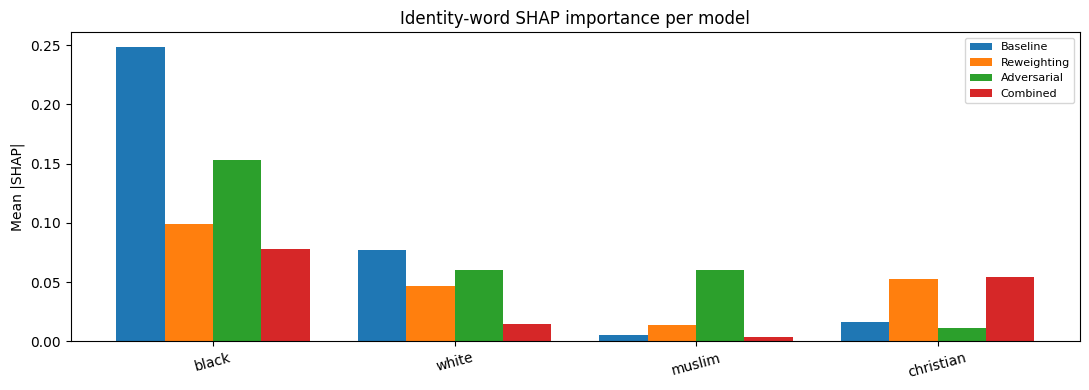

In [15]:
if HAS_SHAP and SHAP_VALS:
    # Aggregate mean |SHAP| per word across all sample texts
    word_imp = {name: {} for name in MODELS}
    for name, sv in SHAP_VALS.items():
        for i, text in enumerate(shap_texts):
            words = text.split()
            vals  = sv[i].values
            for j, w in enumerate(words):
                if j >= len(vals): break
                key = w.lower().strip('.,!?"\'')
                word_imp[name].setdefault(key, []).append(abs(float(vals[j])))
        word_imp[name] = {k: float(np.mean(v)) for k, v in word_imp[name].items()}

    # Identity vs. other word importance ratio
    rows = []
    for name, wi in word_imp.items():
        id_vals   = [v for k, v in wi.items() if k in IDENTITY_WORDS]
        non_vals  = [v for k, v in wi.items() if k not in IDENTITY_WORDS]
        id_mean   = float(np.mean(id_vals))  if id_vals  else 0.0
        non_mean  = float(np.mean(non_vals)) if non_vals else 0.0
        ratio     = id_mean / non_mean if non_mean > 0 else float('nan')
        rows.append({'Model': name, 'Avg |SHAP| identity': f'{id_mean:.4f}',
                     'Avg |SHAP| other': f'{non_mean:.4f}', 'Ratio (id/other)': f'{ratio:.2f}'})
    print('SHAP importance: identity words vs. other words')
    print(pd.DataFrame(rows).to_string(index=False))

    # Top identity words by |SHAP| for each model
    print('\nTop 8 identity words by mean |SHAP|:')
    for name, wi in word_imp.items():
        id_wi   = {k: v for k, v in wi.items() if k in IDENTITY_WORDS}
        top5    = sorted(id_wi.items(), key=lambda x: x[1], reverse=True)[:8]
        top_str = '  '.join(f'{k}({v:.3f})' for k, v in top5)
        print(f'  {name:<14}: {top_str}')

    # Visualise: bar chart comparing mean |SHAP| for key identity words across models
    common_id = [w for w in ['black', 'white', 'muslim', 'christian', 'transgender', 'gay']
                 if any(w in word_imp[n] for n in MODELS)]
    x = np.arange(len(common_id)); w = 0.2
    fig, ax = plt.subplots(figsize=(11, 4))
    for k, (name, wi) in enumerate(word_imp.items()):
        vals = [wi.get(word, 0.0) for word in common_id]
        ax.bar(x + k * w, vals, w, label=name)
    ax.set_xticks(x + w * 1.5); ax.set_xticklabels(common_id, rotation=15)
    ax.set_ylabel('Mean |SHAP|'); ax.set_title('Identity-word SHAP importance per model')
    ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## 7. Analyse de robustesse

Nous perturbons les commentaires de test de trois manières contrôlées et mesurons la dégradation de l'AUC :

| Perturbation | Simule |
|---|---|
| **Bruit au niveau caractère** | Erreurs OCR, fautes de frappe, obfuscation volontaire |
| **Dropout de mots** | Entrée partielle, artefacts de résumé, masquage |
| **Troncature** | Entrées courtes, limites de caractères (mobile / API) |


In [16]:
rng = np.random.RandomState(SEED)

def char_noise(text, rate):
    if rate == 0: return text
    chars = list(str(text))
    n   = max(1, int(len(chars) * rate))
    idx = rng.choice(len(chars), min(n, len(chars)), replace=False)
    for i in idx: chars[i] = chr(rng.randint(97, 123))
    return ''.join(chars)

def word_dropout(text, rate):
    words = str(text).split()
    if not words or rate == 0: return text
    n   = max(1, int(len(words) * rate))
    idx = rng.choice(len(words), min(n, len(words)), replace=False)
    for i in idx: words[i] = ''
    return ' '.join(words)

def truncate_words(text, max_w):
    return ' '.join(str(text).split()[:int(max_w)])

def robustness_auc(model, texts, labels):
    model.eval()
    all_scores = []
    ids = torch.tensor([encode(t) for t in texts], dtype=torch.long)
    with torch.no_grad():
        for i in range(0, len(ids), BATCH_SIZE):
            out = model(ids[i:i+BATCH_SIZE].to(DEVICE))
            if isinstance(out, tuple): out = out[0]
            all_scores.extend(out.cpu().tolist())
    return float(roc_auc_score(labels, all_scores))

# Use a subsample for speed
rob_df    = test_df.sample(n=ROBUSTNESS_N, random_state=SEED).reset_index(drop=True)
orig_txt  = rob_df['comment_text'].tolist()
labels    = rob_df['toxic'].values

NOISE_LEVELS  = [0.0, 0.05, 0.10, 0.20]
DROPOUT_RATES = [0.0, 0.10, 0.20, 0.30]
TRUNC_WORDS   = [128, 64, 32, 16]   # approximate word count

ROB_RESULTS = {}
for perturb_name, levels, pfn in [
    ('Char noise',   NOISE_LEVELS,  char_noise),
    ('Word dropout', DROPOUT_RATES, word_dropout),
    ('Truncation',   TRUNC_WORDS,   truncate_words),
]:
    ROB_RESULTS[perturb_name] = {}
    for name, model in MODELS.items():
        aucs = []
        for lvl in levels:
            ptxt = [pfn(t, lvl) for t in orig_txt]
            aucs.append(robustness_auc(model, ptxt, labels))
        ROB_RESULTS[perturb_name][name] = aucs
    print(f'{perturb_name}: done')

# Print AUC table per perturbation
for perturb_name, levels in [
    ('Char noise',   NOISE_LEVELS),
    ('Word dropout', DROPOUT_RATES),
    ('Truncation',   TRUNC_WORDS),
]:
    df_rob = pd.DataFrame(ROB_RESULTS[perturb_name], index=levels).round(4)
    df_rob.index.name = perturb_name
    print(f'\n{df_rob.to_string()}')

Char noise: done
Word dropout: done
Truncation: done

            Baseline  Reweighting  Adversarial  Combined
Char noise                                              
0.00          0.9514       0.9485       0.9516    0.9470
0.05          0.8722       0.8952       0.8751    0.8757
0.10          0.8244       0.8206       0.8001    0.8172
0.20          0.6881       0.6982       0.6546    0.6948

              Baseline  Reweighting  Adversarial  Combined
Word dropout                                              
0.0             0.9514       0.9485       0.9516    0.9470
0.1             0.9290       0.9282       0.9297    0.9216
0.2             0.9038       0.9224       0.9160    0.9081
0.3             0.8999       0.8812       0.8962    0.8835

            Baseline  Reweighting  Adversarial  Combined
Truncation                                              
128           0.9514       0.9485       0.9516    0.9470
64            0.9363       0.9322       0.9365    0.9299
32            0.9050

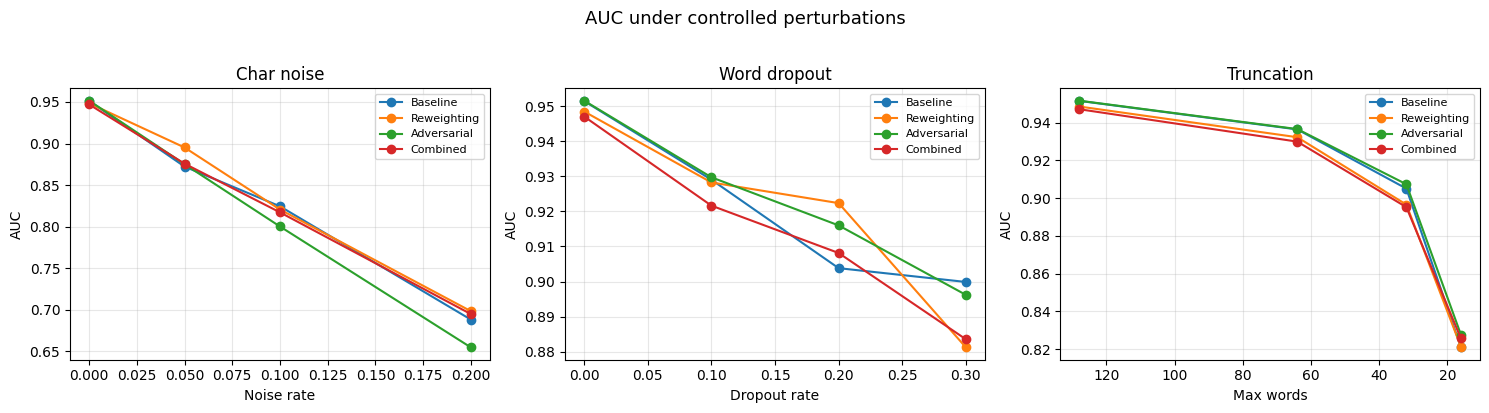


Relative AUC drop (vs. clean input):
  Char noise
    Baseline      : +0.000  +0.079  +0.127  +0.263
    Reweighting   : +0.000  +0.053  +0.128  +0.250
    Adversarial   : +0.000  +0.076  +0.151  +0.297
    Combined      : +0.000  +0.071  +0.130  +0.252
  Word dropout
    Baseline      : +0.000  +0.022  +0.048  +0.052
    Reweighting   : +0.000  +0.020  +0.026  +0.067
    Adversarial   : +0.000  +0.022  +0.036  +0.055
    Combined      : +0.000  +0.025  +0.039  +0.063
  Truncation
    Baseline      : +0.000  +0.015  +0.046  +0.130
    Reweighting   : +0.000  +0.016  +0.052  +0.127
    Adversarial   : +0.000  +0.015  +0.044  +0.124
    Combined      : +0.000  +0.017  +0.052  +0.121


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
for ax, (pname, levels, xlabel) in zip(axes, [
    ('Char noise',   NOISE_LEVELS,  'Noise rate'),
    ('Word dropout', DROPOUT_RATES, 'Dropout rate'),
    ('Truncation',   TRUNC_WORDS,   'Max words'),
]):
    for name, aucs in ROB_RESULTS[pname].items():
        ax.plot(levels, aucs, marker='o', label=name)
    ax.set_title(pname); ax.set_xlabel(xlabel); ax.set_ylabel('AUC')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    if pname == 'Truncation': ax.invert_xaxis()   # severity increases left-to-right
plt.suptitle('AUC under controlled perturbations', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Relative AUC degradation vs. clean (level=0 / max_words=128)
print('\nRelative AUC drop (vs. clean input):')
for pname, levels in [
    ('Char noise',   NOISE_LEVELS),
    ('Word dropout', DROPOUT_RATES),
    ('Truncation',   TRUNC_WORDS),
]:
    print(f'  {pname}')
    for name, aucs in ROB_RESULTS[pname].items():
        drops = [aucs[0] - a for a in aucs]
        print(f'    {name:<14}: ' + '  '.join(f'{d:+.3f}' for d in drops))

## 8. Conclusions

**Biais du jeu de données.** Quatre identités portent le biais d'étiquetage confirmé le plus fort : `black` (≈31 %, *r* partiel = 0,16), `homosexual_gay_or_lesbian` (≈28 %, *r* = 0,15), `white` (≈28 %, *r* = 0,13), `muslim` (≈23 %, *r* = 0,11). Le sous-ensemble annoté est 1,4× plus toxique que le corpus complet, ce qui reflète une sur-échantillonnage à l'annotation.

---

**Comparaison des quatre modèles — moyennes sur 18 sous-groupes.**

| Métrique | Baseline | Répondération | Adversarial | Combiné |
|--------|:--------:|:-----------:|:-----------:|:--------:|
| AUC globale | **0,9517** | 0,9504 | 0,9503 | 0,9477 |
| Taux toxique prédit | 5,04 % | 5,57 % | 5,36 % | 5,29 % |
| Rappel toxique | 51 % | **54 %** | 53 % | 52 % |
| *AUC moyenne sous-groupe* | **0,838** | 0,833 | 0,832 | 0,825 |
| *AUC BPSN moyenne* | 0,864 | 0,890 | 0,873 | **0,899** |
| *AUC épinglée moyenne* | 0,874 | **0,877** | 0,873 | 0,873 |
| *Écart FPR moyen* | 0,016 | 0,007 | 0,022 | **0,003** |
| ECE globale | 0,010 | **0,005** | **0,005** | 0,006 |
| *ECE moyenne sous-groupe* | **0,056** | 0,067 | 0,058 | 0,087 |
| *Ratio SHAP id/autre* | 10,33 | 6,33 | 7,79 | **4,91** |

**Métriques par identité sélectionnées (Baseline / Répondération / Adversarial / Combiné ; gras = meilleur).**

| Identité | AUC BPSN | Écart FPR |
|----------|:--------:|:-------:|
| `black` | 0,799 / 0,862 / 0,842 / **0,894** | +0,041 / +0,007 / +0,037 / **+0,002** |
| `homosexual_gay_or_lesbian` | 0,801 / 0,853 / 0,832 / **0,877** | +0,044 / +0,016 / +0,053 / **+0,009** |
| `transgender` | 0,839 / 0,872 / 0,863 / **0,893** | +0,016 / +0,006 / +0,027 / **−0,002** |
| `muslim` | 0,825 / 0,872 / 0,849 / **0,890** | +0,031 / +0,007 / +0,032 / **+0,005** |
| `white` | 0,807 / 0,872 / 0,848 / **0,901** | +0,037 / +0,005 / +0,031 / **+0,002** |
| `christian` | **0,928** / **0,928** / 0,908 / 0,914 | −0,000 / +0,001 / +0,005 / **−0,001** |

**Pourquoi ces six identités.** `black`, `homosexual_gay_or_lesbian`, `white` et `muslim` sont les quatre cibles principales de biais confirmées par l'EDA (écart DP > 11 pp, *r* partiel ≥ 0,11) — les groupes pour lesquels la mitigation compte le plus. `transgender` (*r* partiel ≈ 0,05) teste si les gains se généralisent à des groupes au biais plus faible mais réel. `christian` (taux toxique sous la baseline, *r* partiel ≈ 0,01) sert de contrôle : les mitigations ne doivent pas le dégrader.

**Constats au niveau identité.** Combiné domine l'AUC BPSN pour les cinq groupes à fort biais, avec les gains les plus marqués sur `black` (+0,095 vs. Baseline) et `homosexual_gay_or_lesbian` (+0,076). Adversarial dégrade l'écart FPR pour quatre des six groupes — le plus fortement pour `homosexual_gay_or_lesbian` (+0,053) et `transgender` (+0,027), tous deux pires que Baseline, ce qui confirme qu'avec la GRL à `LAMBDA_ADV = 0,5` sur 3 époques on augmente plutôt qu'on ne réduit le sur-déclenchement. `christian` reste stable sur tous les modèles (AUC BPSN 0,908–0,928, écart FPR quasi nul) : pas de sur-correction.

---

**Vue d'ensemble.** Chaque mitigation coûte 0,001–0,004 AUC par rapport à Baseline (0,9517). Tous les modèles sous-prédisent : taux toxique prédit 5–6 % contre 8 % réel.

**AUC.** Combiné obtient la meilleure AUC BPSN (0,899) ; Répondération la meilleure AUC épinglée (0,877). Les gains s'échelonnent avec la gravité du biais — les plus forts pour `black` et `homosexual_gay_or_lesbian`.

**Écart FPR.** Combiné (0,003) et Répondération (0,007) réduisent le sur-déclenchement. Adversarial l'aggrave (0,022 > Baseline 0,016) ; l'écart FPR pour `homosexual_gay_or_lesbian` culmine à 0,053 — le pire des quatre modèles.

**ECE.** Répondération et Adversarial ex aequo sur l'ECE globale 0,005. Les mitigations introduisent une mauvaise calibration par sous-groupe : Combiné est le pire (0,087), Baseline le meilleur (0,056).

**SHAP.** Combiné réduit le plus le ratio SHAP identité/autre (10,33 → 4,91). Le jeton `black` en |SHAP| passe de 0,248 (Baseline) à 0,078 (Combiné, −68 %). Adversarial produit la suppression la plus faible (7,79).

**Robustesse.** À 20 % de bruit caractère, tous les modèles perdent 0,25–0,30 AUC ; Adversarial est le pire (−0,297), Répondération la plus résiliente. Le dropout de mots et la troncature montrent une dégradation modérée et globalement uniforme.

**Enseignement.**

| Cas d'usage | Meilleur modèle | Atout principal |
|----------|-----------|---------------|
| Minimiser les faux positifs sur les groupes identitaires | **Combiné** | Meilleure AUC BPSN (0,899) et écart FPR (0,003) |
| Scores sensibles à la calibration | **Répondération** | ECE globale 0,005, meilleure ECE sous-groupe que Combiné |
| Environnements bruités / entrées courtes | **Répondération** | La plus résiliente au bruit caractère |

Aucun modèle ne domine toutes les métriques. L'adversaire GRL avec les réglages actuels (`LAMBDA_ADV = 0,5`, 3 époques) est trop faible — il dégrade le FPR sans réduire nettement le SHAP. Prochaines étapes prioritaires : augmenter `LAMBDA_ADV`, prolonger l'entraînement, ou remplacer le GRU par un backbone transformeur pré-entraîné.
